In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def build_long_df(model_dfs, level_col, metric_col):
    """
    model_dfs: dict {model_name: df}
       Each df must contain `level_col` and `metric_col`.
    level_col: str, e.g. "top" or "bottom"
    metric_col: str, e.g. "sbert_cosine_mean"
    
    Returns a long df with columns: [level_col, "model", "metric"]
    """
    frames = []
    for model_name, df in model_dfs.items():
        if level_col not in df.columns:
            raise ValueError(f"{level_col} not in columns for model {model_name}")
        if metric_col not in df.columns:
            raise ValueError(f"{metric_col} not in columns for model {model_name}")
        
        tmp = df[[level_col, metric_col]].copy()
        tmp["model"] = model_name
        tmp = tmp.rename(columns={metric_col: "metric"})
        frames.append(tmp)
    
    long_df = pd.concat(frames, ignore_index=True)
    return long_df


In [6]:
def plot_models_by_category(long_df, level_col, metric_name=None, sort_by="mean"):
    """
    long_df: output of build_long_df (columns: level_col, 'model', 'metric')
    level_col: "top" or "bottom"
    metric_name: label for x-axis, e.g. "SBERT cosine"
    sort_by: "mean" (avg across models) or a specific model name
    """
    # Decide category order
    if sort_by == "mean":
        order = (
            long_df.groupby(level_col)["metric"]
            .mean()
            .sort_values(ascending=False)
            .index
        )
    else:
        # Sort by a specific model's metric
        tmp = (
            long_df[long_df["model"] == sort_by]
            .groupby(level_col)["metric"]
            .mean()
            .sort_values(ascending=False)
        )
        order = tmp.index

    # Pivot for plotting: rows = category, columns = model
    wide = long_df.pivot_table(
        index=level_col,
        columns="model",
        values="metric",
        aggfunc="mean"
    ).loc[order]

    models = list(wide.columns)
    n_models = len(models)
    categories = list(wide.index)
    n_cat = len(categories)

    # Horizontal grouped bar plot
    fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * n_cat)))

    y_pos = range(n_cat)
    total_width = 0.8
    bar_width = total_width / max(1, n_models)

    for i, model in enumerate(models):
        offsets = [y + (i - (n_models-1)/2) * bar_width for y in y_pos]
        ax.barh(offsets, wide[model], height=bar_width, label=model)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(categories)
    ax.invert_yaxis()
    ax.set_xlabel(metric_name or "metric")
    ax.set_title(f"{metric_name or 'Metric'} by {level_col}-level category")
    ax.legend()
    plt.tight_layout()
    plt.show()


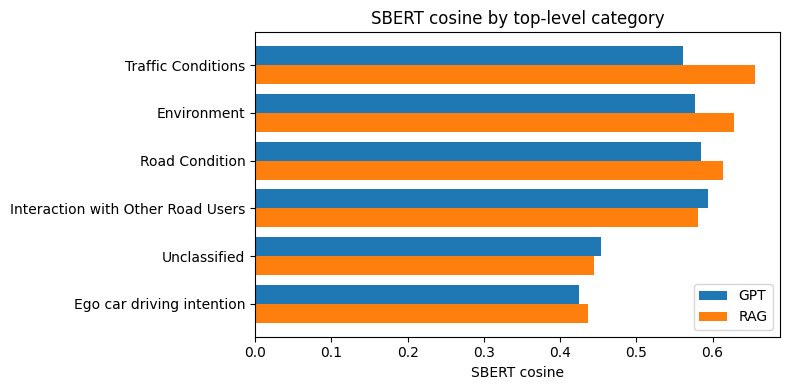

In [7]:
# METRIC_COL = "sbert_cosine_mean"

# Read once
df_top_rag = pd.read_csv("eval_outputs_rag_driver/metrics_per_top.csv")
df_top_gpt = pd.read_csv("eval_outputs_gpt4o/metrics_per_top.csv")

model_dfs_top = {
    "RAG": df_top_rag,
    "GPT": df_top_gpt,
}

# Choose which metric and level
metric_col = "sbert_cosine_mean"
# metric_col = "bert_F1_mean"
# metric_col = "rouge_l_f1_mean"
# metric_col = "meteor_mean"
metric_col_name = "SBERT cosine" if metric_col == "sbert_cosine_mean"  else ""
metric_col_name = "ROUGE-L F1" if metric_col == "rouge_l_f1_mean" else metric_col_name 
metric_col_name = "METEOR" if metric_col == "meteor_mean" else metric_col_name
level_col = "top"

# Build long df
df_long_top = build_long_df(model_dfs_top, level_col=level_col, metric_col=metric_col)

# Plot, sorted by mean across models
plot_models_by_category(
    df_long_top,
    level_col=level_col,
    metric_name=metric_col_name,
    sort_by="mean"           # or "RAG" / "GPT" to sort by a specific model
)


In [8]:
import pandas as pd

# =========================
# INPUT: your existing dataframes
# =========================
# df_top_rag = pd.read_csv("eval_outputs_rag_driver/metrics_per_top.csv")
# df_top_gpt = pd.read_csv("eval_outputs_gpt4o/metrics_per_top.csv")

model_dfs_top = {
    "RAG": df_top_rag,
    "GPT": df_top_gpt,
}

# =========================
# METRICS FOR THE TABLE
# =========================
metrics = {
    "sbert_cosine_mean": "SBERT",
    "bert_F1_mean": "BERT-F1",
    "rougeL_F1_mean": "ROUGE-L",
    "meteor_mean": "METEOR",
}

level_col = "top"

# =========================
# BUILD LONG DF FOR *ALL* METRICS
# =========================
rows = []
for model_name, df in model_dfs_top.items():
    for _, r in df.iterrows():
        row = {
            level_col: r[level_col],
            "model": model_name,
        }
        for m in metrics.keys():
            row[m] = r[m]
        rows.append(row)

df_long_top = pd.DataFrame(rows)
df_long_top["model"] = pd.Categorical(df_long_top["model"], categories=["RAG", "GPT"], ordered=True)

# =========================
# ADD AGGREGATED "ALL DATA"
# =========================
rows_all = []
for model in ["RAG", "GPT"]:
    subset = df_long_top[df_long_top["model"] == model]
    row = {
        level_col: "All Data",
        "model": model,
        **{m: subset[m].mean() for m in metrics.keys()}
    }
    rows_all.append(row)

df_all = pd.DataFrame(rows_all)
df_aug = pd.concat([df_all, df_long_top], ignore_index=True)

# =========================
# BUILD TABLE STRUCTURE
# =========================
categories = df_aug[level_col].unique()

rows_table = []
for cat in categories:
    df_cat = df_aug[df_aug[level_col] == cat].sort_values("model")
    for _, r in df_cat.iterrows():
        row = {
            "Scenario": cat,
            "Method": r["model"],
        }
        for m_col, m_name in metrics.items():
            row[m_name] = f"{r[m_col]:.4f}"
        rows_table.append(row)

df_table = pd.DataFrame(rows_table)

# =========================
# LATEX OUTPUT
# =========================
caption = "Justification performance of GPT and RAG across first-level scenario categories."
label = "tab:justification_performance_full"

latex = df_table.to_latex(
    index=False,
    escape=True,
    column_format="l|c|" + "c" * len(metrics),
    caption=caption,
    label=label,
)

with open("table_full_metrics_top.tex", "w") as f:
    f.write(latex)

print(latex)


\begin{table}
\caption{Justification performance of GPT and RAG across first-level scenario categories.}
\label{tab:justification_performance_full}
\begin{tabular}{l|c|cccc}
\toprule
Scenario & Method & SBERT & BERT-F1 & ROUGE-L & METEOR \\
\midrule
All Data & GPT & 0.5325 & 0.8768 & 0.1914 & 0.1292 \\
All Data & RAG & 0.5601 & 0.8974 & 0.3243 & 0.2150 \\
Traffic Conditions & GPT & 0.5613 & 0.8899 & 0.2749 & 0.1902 \\
Traffic Conditions & RAG & 0.6557 & 0.9143 & 0.4537 & 0.3131 \\
Environment & GPT & 0.5772 & 0.8790 & 0.2039 & 0.1438 \\
Environment & RAG & 0.6288 & 0.9083 & 0.4308 & 0.2833 \\
Road Condition & GPT & 0.5846 & 0.8790 & 0.1755 & 0.1249 \\
Road Condition & RAG & 0.6140 & 0.9035 & 0.3500 & 0.2550 \\
Interaction with Other Road Users & GPT & 0.5942 & 0.8790 & 0.1961 & 0.1224 \\
Interaction with Other Road Users & RAG & 0.5812 & 0.8975 & 0.3074 & 0.2042 \\
Unclassified & GPT & 0.4533 & 0.8671 & 0.1446 & 0.0978 \\
Unclassified & RAG & 0.4440 & 0.8806 & 0.1894 & 0.1103 \\
Ego ca